In [1]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

def check_overfitting(model, X_train, X_test, y_train, y_test, model_name="Model"):


    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)


    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)


    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    print(f" Overfitting Check")
    print(f"Train R²: {train_r2:.3f}")
    print(f"Test  R²: {test_r2:.3f}")
    print(f"Train RMSE: {train_rmse:.3f}")
    print(f"Test  RMSE: {test_rmse:.3f}")

    # 判斷
    if train_r2 - test_r2 > 0.10 and train_r2 > 0.80:
        print("判定：Overfitting")
    elif test_r2 < 0.20 and train_r2 > test_r2:
        print("高度懷疑")
    else:
        print("未過擬合")

    return train_r2, test_r2


C:\Users\sara9\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================
# 1. 讀取與清理資料
# =========================
df = pd.read_csv('NBA_Normalized_Final.csv')

bool_cols = ['Is_Undrafted', 'Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().map({"TRUE": 1, "FALSE": 0})

# =========================
# 2. 篩選資料 
# =========================
df_g = df[(df['season'] > 1) & (df['year_start'] > 1999)].copy()

feature_cols = [
    '2P%','2PA','3P','3P%','3PA','3PAr','AST','AST%','BLK','BLK%','BPM','DBPM',
    'DRB','DRB%','DWS','FG','FG%','FGA','FT','FT%','FTA','FTr',
    'OBPM','ORB','ORB%','OWS','PER','PF','PTS','Pos_C','Pos_PF','Pos_PG',
    'Pos_SF','Pos_SG','STL','STL%','TOV','TOV%','TRB','TRB%','TS%','USG%',
    'VORP','WS','WS/48','eFG%'
]
target_col = 'Year3_WS'

# 清洗目標值與特徵值
data = df_g.dropna(subset=[target_col]).copy()
for c in feature_cols:
    data[c] = pd.to_numeric(data[c], errors='coerce')
data[target_col] = pd.to_numeric(data[target_col], errors='coerce')
data = data.dropna(subset=[target_col]).copy()

X = data[feature_cols].copy()
y = data[target_col].copy()

# =========================
# 3. 切分訓練 / 測試
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. RidgeCV
# =========================
alphas = np.logspace(-4, 4, 60)
cv_splits = min(5, len(X_train))

ridge_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=alphas, cv=cv_splits, scoring='r2')) 
])

ridge_pipe.fit(X_train, y_train)

# 計算各項 R2
train_r2 = r2_score(y_train, ridge_pipe.predict(X_train))
best_cv_r2 = ridge_pipe.named_steps["model"].best_score_
test_r2 = r2_score(y_test, ridge_pipe.predict(X_test))

# 計算其他指標 
y_pred_test = ridge_pipe.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

# =========================
# 5. 輸出結果
# =========================
print("\n" + "="*40)
print("       RIDGE REGRESSION FINAL REPORT")
print("="*40)
print(f"1. Train R²:   {train_r2:.4f}")
print(f"2. Best CV R² :  {best_cv_r2:.4f}")
print(f"3. Test R²:   {test_r2:.4f}")
print("-"*40)
print(f"Chosen Alpha :     {ridge_pipe.named_steps['model'].alpha_:.4f}")
print(f"Test RMSE:                {rmse_test:.4f}")
print(f"Test MAE:                 {mae_test:.4f}")
print("="*40)

# =========================
# 6. 特徵係數排名 
# =========================
coefs = ridge_pipe.named_steps["model"].coef_
coef_df = pd.DataFrame({"feature": feature_cols, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()
print(coef_df.sort_values("abs_coef", ascending=False).head(10)[["feature", "coef"]])


       RIDGE REGRESSION FINAL REPORT
1. Train R² (訓練集得分):   0.5155
2. Best CV R² (交叉驗證):  0.4629
3. Test R² (實測測試集):   0.4543
----------------------------------------
Chosen Alpha (最佳 λ):     172.6983
Test RMSE:                2.0085
Test MAE:                 1.6129

前 10 大關鍵特徵:
   feature      coef
25     OWS  0.476214
42    VORP  0.430468
43      WS  0.427055
14     DWS  0.234656
30  Pos_PF -0.163265
34     STL  0.118415
16     FG% -0.111576
6      AST  0.104981
39    TRB%  0.103017
36     TOV  0.091420


篩選後的資料：
              Player  year_start  DraftRank  Is_Undrafted  season  Is_Active  \
1323   Chucky Atkins        2000        200             1      11      False   
1324     Cal Bowdler        2000         17             0       3      False   
1325      Ryan Bowen        2000         55             0      10      False   
1326   Rodney Buford        2000         53             0       5      False   
1327  Anthony Carter        2000        200             1      13      False   

      Salary_Cap_At_Start  BRI_Factor  Salary_Percentage  Year3_WS  ...   OWS  \
1323                 35.5        0.57             1.0000       5.1  ...  1.15   
1324                 35.5        0.57             1.9403       0.5  ...  0.30   
1325                 35.5        0.57             1.0000       3.1  ...  1.00   
1326                 35.5        0.57             1.0000       0.8  ...  0.10   
1327                 35.5        0.57             1.0000       0.2  ... -0.90   

       DWS    WS   WS/48

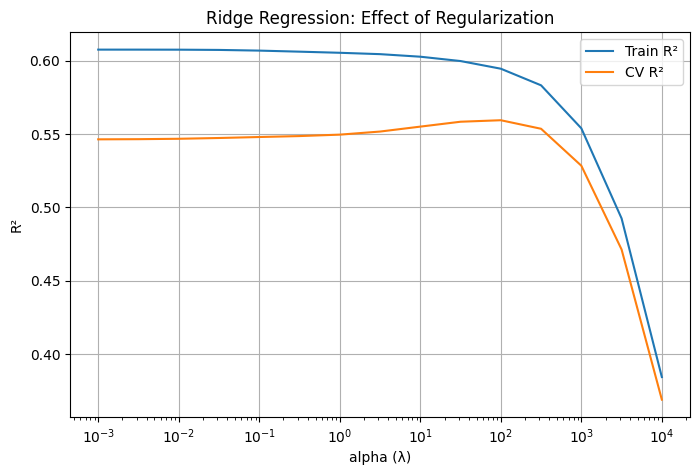

In [47]:
#模型比較
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# =========================
# 1.準備資料
# =========================
df = pd.read_csv("NBA_Normalized_Final.csv")

bool_cols = [
    'Is_Undrafted',
    'Pos_PG',
    'Pos_C',
    'Pos_SG',
    'Pos_SF',
    'Pos_PF'
]  

for col in bool_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.upper()
        .map({"TRUE": 1, "FALSE": 0})
    )


df_g = df[(df['season'] > 1)&(df['year_start']>1999)].copy()



# 去除有缺值的資料列
feature_cols = ['2P%','2PA','3P','3P%','3PA','3PAr','AST','AST%','BLK','BLK%','BPM','DBPM','DRB','DRB%','DWS','DraftRank','FG','FG%','FGA','FT','FT%','FTA','FTr','OBPM','ORB','ORB%','OWS','PER','PF','PTS','Pos_C','Pos_PF','Pos_PG','Pos_SF','Pos_SG','STL','STL%','TOV','TOV%','TRB','TRB%','TS%','USG%','VORP','WS','WS/48','eFG%','Is_Undrafted']
target_col = 'Year3_WS'


data = df_g.dropna(subset=feature_cols + [target_col])

X = data[feature_cols]
y = data[target_col] 

# =========================
# 2.設定 λ（alpha）範圍
# =========================
alphas = np.logspace(-3, 4, 15)  

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

# =========================
# 3.測試每個 λ
# =========================
for a in alphas:
    model = Pipeline([
        ("scaler", StandardScaler()),  
        ("ridge", Ridge(alpha=a))
    ])

    scores = cross_validate(
        model, X, y,
        cv=cv,
        scoring="r2",
        return_train_score=True
    )

    results.append({
        "alpha": a,
        "train_r2": scores["train_score"].mean(),
        "val_r2": scores["test_score"].mean(),
        "val_std": scores["test_score"].std()
    })

results_df = pd.DataFrame(results)

print("測試結果")
print(results_df)
best = results_df.loc[results_df["val_r2"].idxmax()]
print("最佳 alpha")
print(best)
results_df["gap"] = results_df["train_r2"] - results_df["val_r2"]

print("Overfitting 檢查")
print(results_df[["alpha", "train_r2", "val_r2", "gap"]])
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.semilogx(results_df["alpha"], results_df["train_r2"], label="Train R²")
plt.semilogx(results_df["alpha"], results_df["val_r2"], label="CV R²")
plt.xlabel("alpha (λ)")
plt.ylabel("R²")
plt.title("Ridge Regression: Effect of Regularization")
plt.legend()
plt.grid(True)
plt.show()


In [7]:
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error
from sklearn.impute import SimpleImputer 

# -------------------------
# 1) 切 train/test
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# -------------------------
# 2) 建立 Ridge
# -------------------------
ridge_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")), 
    ("scaler", StandardScaler()),
    ("ridge", Ridge(
        alpha=ridge_pipe.named_steps['model'].alpha_,  
        random_state=42
    ))
])

# -------------------------
# 3) 訓練
# -------------------------
ridge_model.fit(X_train, y_train)

# -------------------------
# 4) 預測
# -------------------------
y_train_pred = ridge_model.predict(X_train)
y_test_pred  = ridge_model.predict(X_test)

# -------------------------
# 5) 指標：RMSE / MAE / MedianAE
# -------------------------
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(mean_squared_error(y_test, y_test_pred))

mae_test   = mean_absolute_error(y_test, y_test_pred)
medae_test = median_absolute_error(y_test, y_test_pred)

# -------------------------
# 6) CV RMSE mean ± std
# -------------------------
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    ridge_model,
    X_train, y_train,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1
)

cv_rmse = -cv_scores
cv_mean = cv_rmse.mean()
cv_std  = cv_rmse.std(ddof=1)

# -------------------------
# 7) Train–Test Gap
# -------------------------
gap = rmse_test - rmse_train

# -------------------------
# 8) Spearman rank correlation
# -------------------------
def spearman_corr(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    def rankdata(a):
        order = np.argsort(a)
        ranks = np.empty_like(order, dtype=float)
        ranks[order] = np.arange(len(a), dtype=float)
        _, inv, counts = np.unique(a, return_inverse=True, return_counts=True)
        sums = np.bincount(inv, ranks)
        avg = sums / counts
        return avg[inv]

    rt = rankdata(y_true)
    rp = rankdata(y_pred)
    rt = rt - rt.mean()
    rp = rp - rp.mean()
    denom = np.sqrt((rt**2).sum() * (rp**2).sum())
    return float((rt * rp).sum() / denom) if denom != 0 else np.nan

spearman = spearman_corr(y_test, y_test_pred)

# -------------------------
# 9) 輸出結果
# -------------------------
print("\n===== Ridge Regression Evaluation =====")
print(f"RMSE (test): {rmse_test:.6f}")
print(f"MAE  (test): {mae_test:.6f}")
print(f"MedianAE (test): {medae_test:.6f}")
print(f"CV RMSE (train, 5-fold): {cv_mean:.6f} ± {cv_std:.6f}")
print(f"Train–Test Gap (RMSE_test - RMSE_train): {gap:.6f}")
print(f"Spearman rank corr (test): {spearman:.6f}")


===== Ridge Regression Evaluation =====
RMSE (test): 2.008545
MAE  (test): 1.612909
MedianAE (test): 1.355991
CV RMSE (train, 5-fold): 1.978508 ± 0.056441
Train–Test Gap (RMSE_test - RMSE_train): 0.095729
Spearman rank corr (test): 0.638172


In [13]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# =========================
# 1. 讀取資料
# =========================
df_main = pd.read_csv("NBA_Normalized_Final_3.csv")

# TRUE/FALSE 欄位
bool_cols = ['Is_Undrafted']
for col in bool_cols:
    if col in df_main.columns:
        df_main[col] = (
            df_main[col]
            .astype(str)
            .str.strip()
            .str.upper()
            .map({
                "TRUE": 1, "FALSE": 0,
                "1": 1, "0": 0,
                "1.0": 1, "0.0": 0
            })
        )


dummy_cols = ['Pos_PG', 'Pos_C', 'Pos_SG', 'Pos_SF', 'Pos_PF']
for col in dummy_cols:
    if col in df_main.columns:
        df_main[col] = pd.to_numeric(df_main[col], errors='coerce')

exclude_players = [
    'LeBron James','Chris Paul','Kyle Lowry','P.J. Tucker','Kevin Durant',
    'Al Horford','Mike Conley','Jeff Green','Russell Westbrook','Kevin Love',
    'Brook Lopez','Eric Gordon','Nicolas Batum','DeAndre Jordan','James Harden',
    'Stephen Curry','DeMar DeRozan','Jrue Holiday','Paul George'
]

df_train = df_main[
    (df_main["year_start"] != 2000) &
    (df_main["season"] > 2) &
    (~df_main['Player'].isin(exclude_players))
].copy()

df_2000 = df_main[
    (df_main["year_start"] == 2000) &
    (df_main["season"] > 2) &
    (~df_main['Player'].isin(exclude_players)) &
    (df_main['DraftRank'] < 30)
].copy()

# =========================
# 2. 特徵欄位
# =========================
feature_cols = [
    '2P%', '2PA', '3P', '3P%', '3PA', '3PAr', 'AST', 'AST%', 'BLK', 'BLK%',
    'BPM', 'DBPM', 'DRB', 'DRB%', 'DWS', 'DraftRank', 'FG', 'FG%', 'FGA',
    'FT', 'FT%', 'FTA', 'FTr', 'OBPM', 'ORB', 'ORB%', 'OWS', 'PER', 'PF',
    'PTS', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG', 'STL', 'STL%',
    'TOV', 'TOV%', 'TRB', 'TRB%', 'TS%', 'USG%', 'VORP', 'WS', 'WS/48',
    'eFG%', 'Is_Undrafted'
]
target_col = "Year4_WS"


for col in feature_cols:
    if col in df_train.columns:
        df_train[col] = pd.to_numeric(df_train[col], errors='coerce')
    if col in df_2000.columns:
        df_2000[col] = pd.to_numeric(df_2000[col], errors='coerce')

df_train[target_col] = pd.to_numeric(df_train[target_col], errors='coerce')


df_train = df_train.dropna(subset=[target_col]).copy()


df_2000 = df_2000.copy()

X_train = df_train[feature_cols]
y_train = df_train[target_col]
X_pred = df_2000[feature_cols]

print("訓練樣本數：", len(X_train))
print("預測樣本數：", len(X_pred))



# =========================
# 3. 訓練 Ridge 模型
# =========================
best_alpha = 100
final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_alpha))
])

final_model.fit(X_train, y_train)

# =========================
# 4. 預測WS
# =========================
df_2000["Pred_WS"] = final_model.predict(X_pred).ravel()

# =========================
# 5. 經濟參數設定
# =========================
try:
    eco_ref = df_main[df_main["year_start"] == 2000].iloc[0]

    SALARY_CAP_2000 = eco_ref['Salary_Cap_At_Start']
    BRI_FACTOR_2000 = eco_ref['BRI_Factor']

    def get_team_count(year):
        if year >= 2004: return 30
        if year >= 1995: return 29
        if year >= 1989: return 27
        return 23

    TEAM_COUNT_2000 = get_team_count(2005)
    TOTAL_GAMES = 1230

    marginal_value_per_ws = (SALARY_CAP_2000 * TEAM_COUNT_2000 * BRI_FACTOR_2000) / TOTAL_GAMES

except Exception:
    SALARY_CAP_2000 = 35.5
    BRI_FACTOR_2000 = 1.18
    marginal_value_per_ws = (35.5 * 29 * 1.18) / 1230

# =========================
# 6. 價值計算
# =========================
df_2000["Pred_Dollar_Value_M"] = df_2000["Pred_WS"] * marginal_value_per_ws
df_2000["Pred_Salary_Share_Percent"] = (df_2000["Pred_Dollar_Value_M"] / SALARY_CAP_2000) * 100

def get_cost_percent(row):
    rank = row["DraftRank"]
    if 1 <= rank <= 30:
        return 8.0 - (rank - 1) * (6.5 / 29)
    else:
        return 1.1

df_2000["Est_Cost_Percent"] = df_2000.apply(get_cost_percent, axis=1)
df_2000["Pred_ROI"] = df_2000["Pred_Salary_Share_Percent"] / df_2000["Est_Cost_Percent"]
df_2000["Net_Surplus_Percent"] = df_2000["Pred_Salary_Share_Percent"] - df_2000["Est_Cost_Percent"]

# =========================
# 7. 排名與相關性
# =========================
df_2000["Pred_ROI_Rank"] = df_2000["Pred_ROI"].rank(ascending=False, method="min")
df_2000["Actual_ROI_Rank"] = df_2000["ROI"].rank(ascending=False, method="min")

corr_model_roi, _ = spearmanr(df_2000["Pred_ROI_Rank"], df_2000["Actual_ROI_Rank"])

print(f"每單位 WS 市場價值: ${marginal_value_per_ws:.4f}M")
print(f"模型預測 ROI 排名相關性: {corr_model_roi:.4f}\n")

result = df_2000[[
    "Player",
    "DraftRank",
    "Pred_WS",
    "Pred_Dollar_Value_M",
    "Pred_Salary_Share_Percent",
    "Est_Cost_Percent",
    "Net_Surplus_Percent",
    "Pred_ROI"
]].sort_values("Pred_Salary_Share_Percent", ascending=True)

print("球員經濟價值預測")
print(result.tail(15))

訓練樣本數： 1097
預測樣本數： 24
2000年每單位 WS 市場價值: $1.0217M
模型預測 ROI 排名相關性: 0.8513

=== 2000年球員經濟價值預測（前15名） ===
                 Player  DraftRank   Pred_WS  Pred_Dollar_Value_M  \
1365  Vonteego Cummings       26.0  1.978583             2.021533   
1324      Devean George       23.0  2.166163             2.213185   
1358      Scott Padgett       28.0  2.253000             2.301906   
1340      Jumaine Jones       27.0  2.659524             2.717255   
1353   Richard Hamilton        7.0  3.507815             3.583960   
1341       Kenny Thomas       22.0  3.784199             3.866344   
1319     Corey Maggette       13.0  4.055114             4.143140   
1333        James Posey       18.0  4.938453             5.045654   
1342         Lamar Odom        4.0  5.140246             5.251827   
1335        Jason Terry       10.0  7.044811             7.197735   
1314        Baron Davis        3.0  7.613383             7.778649   
1366   Wally Szczerbiak        6.0  7.642758             7.808661   
13

C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Pos_C' 'Pos_PF' 'Pos_PG' 'Pos_SF' 'Pos_SG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
C:\Users\sara9\anaconda3\anaconda\Lib\site-packages\sklearn\impute\_base.py:653: UserWarning: Skipping features without any observed values: ['Pos_C' 'Pos_PF' 'Pos_PG' 'Pos_SF' 'Pos_SG']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


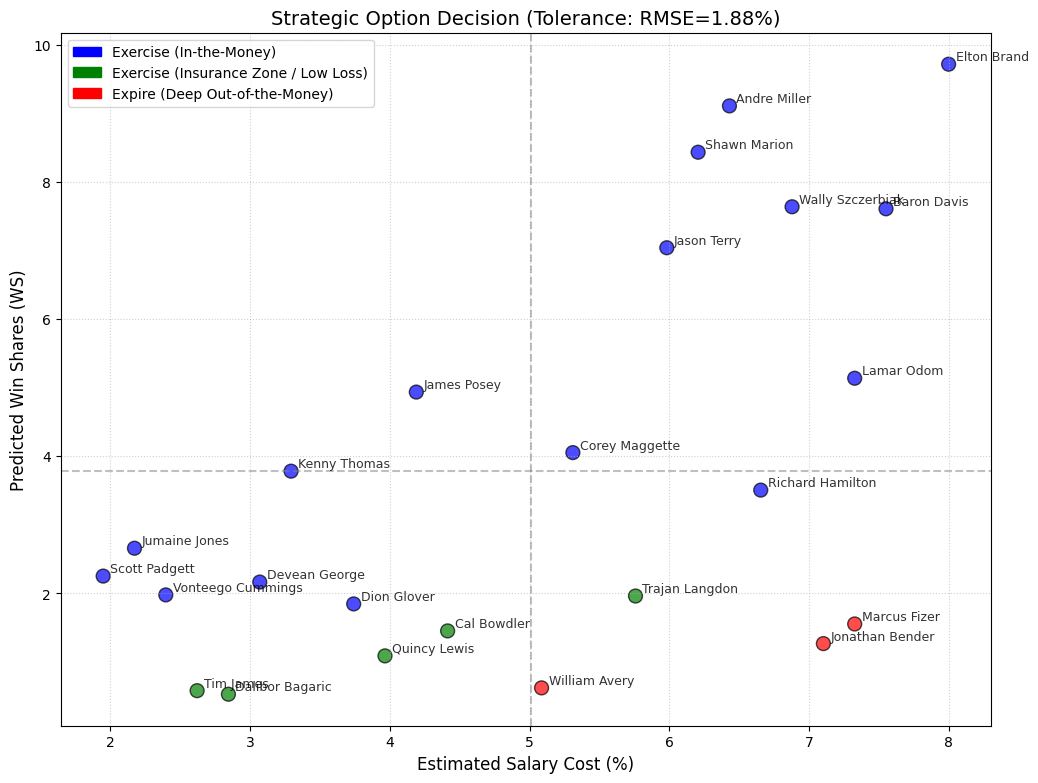

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


rmse_threshold = 1.88  


conditions = [
    (df_2000["Net_Surplus_Percent"] > 0),
    (df_2000["Net_Surplus_Percent"] <= 0) & (df_2000["Net_Surplus_Percent"] >= -rmse_threshold),
    (df_2000["Net_Surplus_Percent"] < -rmse_threshold)
]
choices = ["blue", "green", "red"]
colors = np.select(conditions, choices, default="gray")

plt.figure(figsize=(12, 9))

x = df_2000["Est_Cost_Percent"]
y = df_2000["Pred_WS"]

plt.scatter(
    x, y,
    c=colors,
    s=100,
    alpha=0.7,
    edgecolors="black",
    linewidth=1
)

# 畫象限平均線
plt.axvline(x.mean(), color="gray", linestyle="--", alpha=0.5)
plt.axhline(y.mean(), color="gray", linestyle="--", alpha=0.5)

# 球員姓名
for i, row in df_2000.iterrows():
    plt.text(
        row["Est_Cost_Percent"] + 0.05, 
        row["Pred_WS"] + 0.05,
        row["Player"],
        fontsize=9,
        alpha=0.8
    )

# 標籤與標題
plt.xlabel("Estimated Salary Cost (%)", fontsize=12)
plt.ylabel("Predicted Win Shares (WS)", fontsize=12)
plt.title(f"Strategic Option Decision (Tolerance: RMSE={rmse_threshold}%)", fontsize=14)


blue_patch = mpatches.Patch(color='blue', label='Exercise (In-the-Money)')
green_patch = mpatches.Patch(color='green', label='Exercise (Insurance Zone / Low Loss)')
red_patch = mpatches.Patch(color='red', label='Expire (Deep Out-of-the-Money)')

plt.legend(handles=[blue_patch, green_patch, red_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

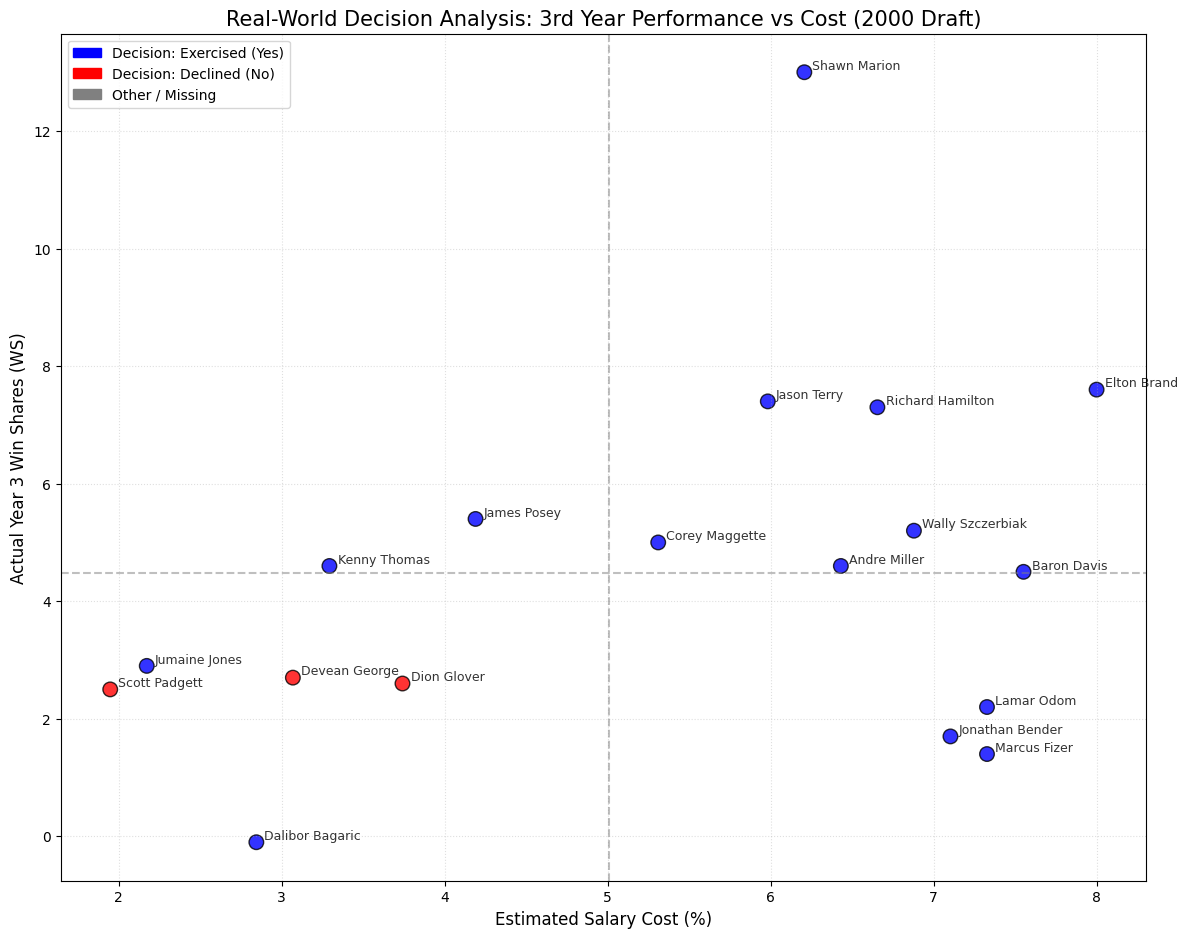

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


df_2000['year_4_clean'] = df_2000['year_4'].astype(str).str.strip().str.lower()
color_map = {'yes': 'blue', 'no': 'red'}
colors = df_2000['year_4_clean'].map(color_map).fillna('gray')

plt.figure(figsize=(14, 11))


x = df_2000["Est_Cost_Percent"]
y = df_2000["Year4_WS"] 


plt.scatter(
    x, y,
    c=colors,
    s=110,          
    alpha=0.8,       
    edgecolors="black",
    linewidth=1
)


plt.axvline(x.mean(), color="gray", linestyle="--", alpha=0.5, label="Avg Cost")
plt.axhline(y.mean(), color="gray", linestyle="--", alpha=0.5, label="Avg WS")


for i, row in df_2000.iterrows():
    plt.text(
        row["Est_Cost_Percent"] + 0.05, 
        row["Year4_WS"] + 0.05, 
        row["Player"], 
        fontsize=9,
        alpha=0.8
    )


plt.xlabel("Estimated Salary Cost (%)", fontsize=12)
plt.ylabel("Actual Year 3 Win Shares (WS)", fontsize=12)
plt.title("Real-World Decision Analysis: 3rd Year Performance vs Cost (2000 Draft)", fontsize=15)


blue_patch = mpatches.Patch(color='blue', label='Decision: Exercised (Yes)')
red_patch = mpatches.Patch(color='red', label='Decision: Declined (No)')
gray_patch = mpatches.Patch(color='gray', label='Other / Missing')

plt.legend(handles=[blue_patch, red_patch, gray_patch], loc='upper left')

plt.grid(True, linestyle=':', alpha=0.4)
plt.show()